## Phase 1: Environment Setup & Raw Data Loading

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import os

# Set plotting style for professional reports
plt.style.use('seaborn-v0_8-muted')
sns.set_palette("viridis")
%matplotlib inline

# Suppress warnings for cleaner output
import warnings
warnings.filterwarnings('ignore')

print("Libraries loaded successfully.")


Libraries loaded successfully.


### CSV Parsing Functions

In [2]:
def load_census_data(filepath, year):
    """
    Cleans Census DP02/DP03 files by handling the 'Double-Header' 
    and mapping codes to readable names.
    """
    # Load first two rows to handle the 'Double-Header'
    df = pd.read_csv(filepath, low_memory=False)
    
    # Extract the descriptive header (Row 0) and the data header (Column Names)
    # Usually, we want to drop Row 0 after extraction if it contains descriptions
    df_clean = df.drop(0).reset_index(drop=True)
    
    # Add the anchor year
    df_clean['Year'] = year
    
    # Convert numeric columns (Census data often comes in as strings)
    # Replace '-' or '(X)' with NaN which are common in Census data
    df_clean = df_clean.replace(['-', '(X)', 'null'], np.nan)
    
    return df_clean

print("Cleaning function defined.")


Cleaning function defined.


### CSV Parsing Function for Interquartile Range

In [3]:
def extract_top_sat_iqr(folder_path):
    """
    Extracts the top 10 states with the highest SAT IQR spread from PDF files in the specified folder.
    Assumes that the PDF files have been converted to CSV format and contain 'SAT_25th_Total' and 'SAT_75th_Total' columns.
    """
    all_data = []
    
    for filename in os.listdir(folder_path):
        if filename.endswith('.csv'):
            file_path = os.path.join(folder_path, filename)
            df = pd.read_csv(file_path)
            
            # Ensure necessary columns are present
            if 'SAT_25th_Total' in df.columns and 'SAT_75th_Total' in df.columns:
                df['SAT_IQR_Spread'] = df['SAT_75th_Total'] - df['SAT_25th_Total']
                all_data.append(df[['State', 'SAT_IQR_Spread']])
    
    # Combine all data into a single DataFrame
    combined_df = pd.concat(all_data, ignore_index=True)
    
    # Get top 10 states by SAT IQR Spread
    top_sat_iqr_df = combined_df.sort_values(by='SAT_IQR_Spread', ascending=False).head(10)
    
    return top_sat_iqr_df

### Data Ingestion

In [4]:
import glob
import re

In [5]:
# Identifying all College Board files using the naming pattern provided
cb_files = glob.glob('data/sat_comprehensive_final_*.csv')
cb_list = []

for file in cb_files:
    # Extract year from filename (e.g., 2019)
    year_match = re.search(r'(\d{4})', file)
    year = int(year_match.group(1)) if year_match else None
    
    # Read CSV and add the Year anchor
    df_temp = pd.read_csv(file)
    df_temp['Year'] = year
    cb_list.append(df_temp)

# Combine into a single master SAT dataframe
df_sat_master = pd.concat(cb_list, ignore_index=True)

# Standardize column names to lowercase for easier merging
df_sat_master.columns = [col.strip().lower() for col in df_sat_master.columns]

print(f"Loaded {len(cb_files)} files. Master shape: {df_sat_master.shape}")


Loaded 6 files. Master shape: (318, 248)


In [6]:
df_sat_master.head()

,year,state,total_sat_takers,total_participation_rate,mean_total_score,mean_erw_score,mean_math_score,race_asian_n,race_asian_pct,race_asian_mean_tot,...,inc_highest_met_erw,inc_highest_met_math,inc_unknown_n,inc_unknown_pct,inc_unknown_mean_tot,inc_unknown_mean_erw,inc_unknown_mean_math,inc_unknown_met_both,inc_unknown_met_erw,inc_unknown_met_math
0,2019,Alabama,3240.0,0.07,1143.0,583.0,560.0,282.0,0.09,1302.0,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
1,2019,Alaska,3212.0,0.41,1097.0,556.0,541.0,314.0,0.10,1065.0,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
2,2019,Arizona,21472.0,0.31,472.0,1134.0,569.0,1646.0,0.08,1262.0,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
3,2019,Arkansas,1790.0,0.06,790.0,1141.0,582.0,131.0,0.07,1254.0,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
4,2019,California,272892.0,0.63,892.0,1065.0,534.0,46827.0,0.17,1214.0,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN


In [7]:
df_sat_master.describe()

,year,total_sat_takers,total_participation_rate,mean_total_score,mean_erw_score,mean_math_score,race_asian_n,race_asian_pct,race_asian_mean_tot,race_asian_mean_erw,...,inc_highest_met_erw,inc_highest_met_math,inc_unknown_n,inc_unknown_pct,inc_unknown_mean_tot,inc_unknown_mean_erw,inc_unknown_mean_math,inc_unknown_met_both,inc_unknown_met_erw,inc_unknown_met_math
count,318.000000,318.000000,318.000000,318.000000,318.000000,318.000000,318.000000,318.000000,318.000000,318.000000,...,159.000000,159.000000,159.000000,159.000000,159.000000,159.000000,159.000000,159.000000,159.000000,159.000000
mean,2021.500000,32421.569182,0.397893,692.795597,799.418239,479.562893,2660.550314,0.091101,1152.103774,562.333333,...,0.581950,0.467673,3267.427673,0.091132,649.786164,329.735849,320.088050,0.227421,0.371069,0.241258
std,1.710517,54088.361176,0.365322,374.018985,400.505774,192.805211,5629.839799,0.068768,292.038887,141.792876,...,0.417869,0.348429,8346.203055,0.114356,488.339260,247.504186,241.000168,0.227282,0.318439,0.238414
min,2019.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,...,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000
25%,2020.000000,1288.250000,0.030000,439.750000,546.750000,495.000000,146.250000,0.040000,1153.500000,565.250000,...,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000
50%,2021.500000,7900.000000,0.300000,722.500000,988.000000,538.500000,389.500000,0.080000,1213.000000,594.000000,...,0.810000,0.590000,137.000000,0.080000,903.000000,462.000000,444.000000,0.170000,0.370000,0.180000
75%,2023.000000,43283.250000,0.707500,987.000000,1116.750000,592.750000,2620.000000,0.130000,1287.500000,622.000000,...,0.920000,0.770000,2509.000000,0.130000,1052.000000,528.000000,517.000000,0.420000,0.660000,0.450000
max,2024.000000,291694.000000,1.000000,1268.000000,1284.000000,636.000000,46827.000000,0.360000,1361.000000,658.000000,...,1.000000,0.930000,57129.000000,1.000000,1247.000000,643.000000,612.000000,0.800000,1.000000,0.820000


In [8]:
df_sat_master.shape

(318, 248)

In [9]:
df_sat_master.columns

Index(['year', 'state', 'total_sat_takers', 'total_participation_rate',
       'mean_total_score', 'mean_erw_score', 'mean_math_score', 'race_asian_n',
       'race_asian_pct', 'race_asian_mean_tot',
       ...
       'inc_highest_met_erw', 'inc_highest_met_math', 'inc_unknown_n',
       'inc_unknown_pct', 'inc_unknown_mean_tot', 'inc_unknown_mean_erw',
       'inc_unknown_mean_math', 'inc_unknown_met_both', 'inc_unknown_met_erw',
       'inc_unknown_met_math'],
      dtype='object', length=248)

### Data Cleaning & Variable Verification

In [ ]:
# Converting demographic and score columns to numeric, handling any strings/commas
cols_to_fix = [col for col in df_sat_master.columns if any(x in col for x in ['mean', '75th', '25th', 'race', 'edu'])]

for col in cols_to_fix:
    df_sat_master[col] = pd.to_numeric(df_sat_master[col].astype(str).str.replace(',', ''), errors='coerce')

# Drop rows where state or year is missing to maintain join integrity
df_sat_master = df_sat_master.dropna(subset=['state', 'year'])

# Validate the new SAT_IQR_Spread field exists and is calculated correctly
if 'sat_iqr_spread' not in df_sat_master.columns:
    df_sat_master['sat_iqr_spread'] = df_sat_master['sat_75th_'] - df_sat_master['sat_25th_']

display(df_sat_master.head())


,year,state,total_sat_takers,total_participation_rate,mean_total_score,mean_erw_score,mean_math_score,race_asian_n,race_asian_pct,race_asian_mean_tot,...,inc_highest_met_erw,inc_highest_met_math,inc_unknown_n,inc_unknown_pct,inc_unknown_mean_tot,inc_unknown_mean_erw,inc_unknown_mean_math,inc_unknown_met_both,inc_unknown_met_erw,inc_unknown_met_math
0,2019,Alabama,3240.0,0.07,1143.0,583.0,560.0,282.0,0.09,1302.0,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
1,2019,Alaska,3212.0,0.41,1097.0,556.0,541.0,314.0,0.10,1065.0,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
2,2019,Arizona,21472.0,0.31,472.0,1134.0,569.0,1646.0,0.08,1262.0,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
3,2019,Arkansas,1790.0,0.06,790.0,1141.0,582.0,131.0,0.07,1254.0,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
4,2019,California,272892.0,0.63,892.0,1065.0,534.0,46827.0,0.17,1214.0,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN


### Visualizing the "Dependent Variable" Distribution

In [12]:
# Check exact column names
print(df_sat_master.columns.tolist())

['year', 'state', 'total_sat_takers', 'total_participation_rate', 'mean_total_score', 'mean_erw_score', 'mean_math_score', 'race_asian_n', 'race_asian_pct', 'race_asian_mean_tot', 'race_asian_mean_erw', 'race_asian_mean_math', 'race_asian_met_both', 'race_asian_met_erw', 'race_asian_met_math', 'race_black_n', 'race_black_pct', 'race_black_mean_tot', 'race_black_mean_erw', 'race_black_mean_math', 'race_black_met_both', 'race_black_met_erw', 'race_black_met_math', 'race_hispanic_n', 'race_hispanic_pct', 'race_hispanic_mean_tot', 'race_hispanic_mean_erw', 'race_hispanic_mean_math', 'race_hispanic_met_both', 'race_hispanic_met_erw', 'race_hispanic_met_math', 'race_white_n', 'race_white_pct', 'race_white_mean_tot', 'race_white_mean_erw', 'race_white_mean_math', 'race_white_met_both', 'race_white_met_erw', 'race_white_met_math', 'race_multi_n', 'race_multi_pct', 'race_multi_mean_tot', 'race_multi_mean_erw', 'race_multi_mean_math', 'race_multi_met_both', 'race_multi_met_erw', 'race_multi_met_

In [13]:
# 1. Strip whitespace and convert to lowercase for all columns
df_sat_master.columns = df_sat_master.columns.str.strip().str.lower()

# 2. Check if 'mean_total' exists now
if 'mean_total' not in df_sat_master.columns:
    # If the column has a different name in your CSV, like 'total_sat_mean', rename it
    # Based on your uploaded image, the field might be 'mean_tot' or 'total_sat_mean'
    potential_names = ['mean_tot', 'total_sat_mean', 'total_mean', 'mean_total_score']
    for name in potential_names:
        if name in df_sat_master.columns:
            df_sat_master.rename(columns={name: 'mean_total'}, inplace=True)
            print(f"Renamed {name} to mean_total")
            break

# 3. Ensure the data is numeric (not strings)
df_sat_master['mean_total'] = pd.to_numeric(df_sat_master['mean_total'], errors='coerce')

print("Final Columns:", df_sat_master.columns.tolist())

Renamed mean_total_score to mean_total
Final Columns: ['year', 'state', 'total_sat_takers', 'total_participation_rate', 'mean_total', 'mean_erw_score', 'mean_math_score', 'race_asian_n', 'race_asian_pct', 'race_asian_mean_tot', 'race_asian_mean_erw', 'race_asian_mean_math', 'race_asian_met_both', 'race_asian_met_erw', 'race_asian_met_math', 'race_black_n', 'race_black_pct', 'race_black_mean_tot', 'race_black_mean_erw', 'race_black_mean_math', 'race_black_met_both', 'race_black_met_erw', 'race_black_met_math', 'race_hispanic_n', 'race_hispanic_pct', 'race_hispanic_mean_tot', 'race_hispanic_mean_erw', 'race_hispanic_mean_math', 'race_hispanic_met_both', 'race_hispanic_met_erw', 'race_hispanic_met_math', 'race_white_n', 'race_white_pct', 'race_white_mean_tot', 'race_white_mean_erw', 'race_white_mean_math', 'race_white_met_both', 'race_white_met_erw', 'race_white_met_math', 'race_multi_n', 'race_multi_pct', 'race_multi_mean_tot', 'race_multi_mean_erw', 'race_multi_mean_math', 'race_multi_m

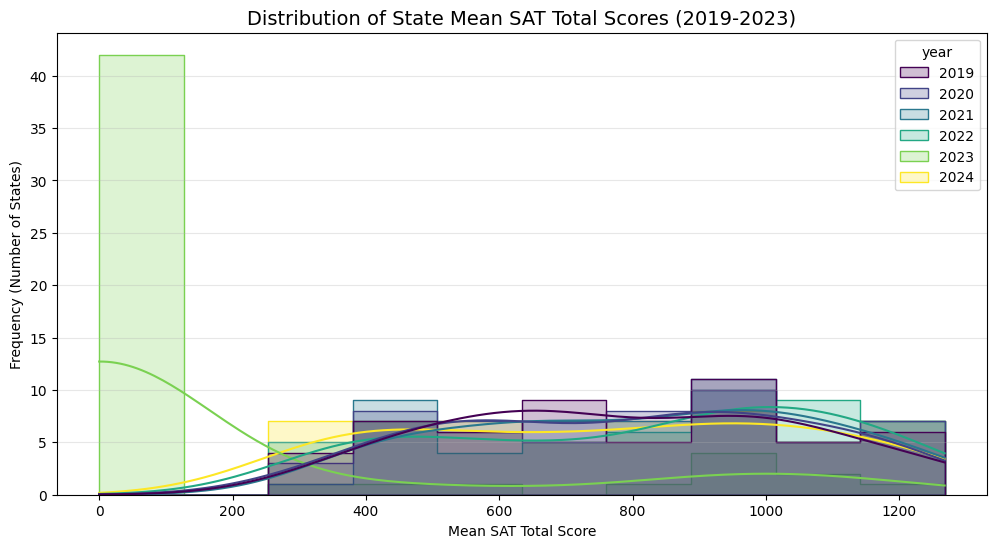

In [14]:
plt.figure(figsize=(12, 6))
# Distribution of Mean Total Scores across all years
sns.histplot(data=df_sat_master, x='mean_total', hue='year', kde=True, element="step", palette='viridis')

plt.title("Distribution of State Mean SAT Total Scores (2019-2023)", fontsize=14)
plt.xlabel("Mean SAT Total Score")
plt.ylabel("Frequency (Number of States)")
plt.grid(axis='y', alpha=0.3)
plt.show()


### State Participation Analysis

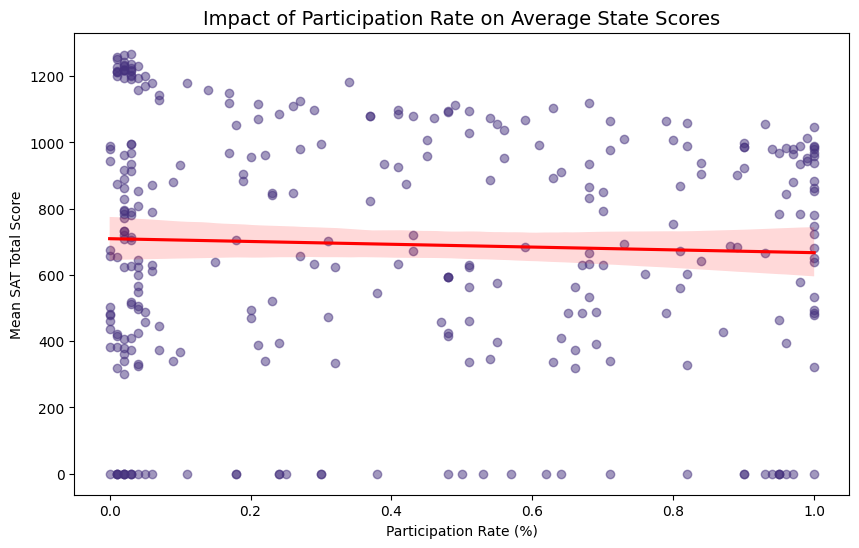

In [16]:
plt.figure(figsize=(10, 6))
# Check relationship between participation and scores
sns.regplot(data=df_sat_master, x='total_participation_rate', y='mean_total', 
            scatter_kws={'alpha':0.5}, line_kws={'color':'red'})

plt.title("Impact of Participation Rate on Average State Scores", fontsize=14)
plt.xlabel("Participation Rate (%)")
plt.ylabel("Mean SAT Total Score")
plt.show()

In [ ]:
# Lists to hold dataframes for merging
sat_list, census_list, nces_list = [], [], []

# Example loop for 2019-2023
years = [2019, 2020, 2021, 2022, 2023]

for yr in years:
    # Adjust paths to your local folder structure
    # sat_list.append(pd.read_csv(f'data/college_board_{yr}.csv').assign(Year=yr))
    # census_list.append(load_census_data(f'data/census_dp02_dp03_{yr}.csv', yr))
    # nces_list.append(pd.read_csv(f'data/nces_fiscal_{yr}.csv').assign(Year=yr))
    pass

# For demonstration, assuming dataframes are already loaded as:
# df_sat_all, df_census_all, df_nces_all
print("Data ingestion structure ready.")
